# Imports & Configuration

In [1]:
!pip install quadprog

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.6/534.6 kB 14.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import zipfile
import random
import numpy as np
import quadprog
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION
# ==========================================
ZIP_PATH = "/content/drive/MyDrive/Projects/MIE424/OfficeHomeDataset_10072016.zip"
DATA_DIR = "/content/officehome_data"
PNG_DIR = "/content/officehome_pngs"
BATCH_SIZE = 256
SPLIT = (0.70, 0.10, 0.20)
SEED = 42
IMAGE_SIZE = 224
NUM_EPOCHS = 10
NUM_CLASSES = 65

DOMAIN_FOLDERS = {
  1: "Art",
  2: "Clipart",
  3: "Product",
  4: "Real World"
}

# ImageNet normalization standard for Office-Home
NORMALIZE = transforms.Normalize(
  mean=[0.485, 0.456, 0.406],
  std =[0.229, 0.224, 0.225]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Processing

In [4]:
def extract_officehome(zip_path: str = ZIP_PATH, data_dir: str = DATA_DIR) -> str:
    os.makedirs(data_dir, exist_ok=True)
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Zip file not found at {zip_path}. Please upload it to Colab.")

    print("Extracting Office-Home dataset ...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")

    extracted = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    root = extracted[0]
    print(f"Dataset root: {root}")
    return root

def get_classes(dataset_root: str) -> list:
    domain_path = os.path.join(dataset_root, "Art")
    classes = sorted([d for d in os.listdir(domain_path) if os.path.isdir(os.path.join(domain_path, d))])
    print(f"Found {len(classes)} classes.")
    return classes

def save_pngs(dataset_root: str, classes: list, png_dir: str = PNG_DIR, split: tuple = SPLIT, seed: int = SEED) -> None:
    rng = np.random.default_rng(seed)
    for domain_id, domain_name in DOMAIN_FOLDERS.items():
        print(f"\nProcessing Domain {domain_id}: {domain_name} ...")
        train_count, val_count, test_count = 0, 0, 0

        for lbl, cls in enumerate(classes):
            src_dir = os.path.join(dataset_root, domain_name, cls)
            if not os.path.exists(src_dir):
                continue

            files = sorted([os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))])
            files = np.array(files)
            rng.shuffle(files)

            n = len(files)
            n_tr = int(n * split[0])
            n_val = int(n * split[1])

            split_map = {
                "train": files[:n_tr],
                "val": files[n_tr:n_tr + n_val],
                "test": files[n_tr + n_val:]
            }

            for split_name, split_files in split_map.items():
                out_dir = os.path.join(png_dir, domain_name, split_name, cls)
                os.makedirs(out_dir, exist_ok=True)
                for i, fpath in enumerate(split_files):
                    try:
                        img = Image.open(fpath).convert("RGB")

                        # Resize the shortest edge to 256 while preserving aspect ratio
                        width, height = img.size
                        if width < height:
                            new_w = 256
                            new_h = int(256 * height / width)
                        else:
                            new_h = 256
                            new_w = int(256 * width / height)

                        img = img.resize((new_w, new_h), Image.BILINEAR)
                        img.save(os.path.join(out_dir, f"{i:05d}.png"))
                    except Exception as e:
                        print(f" Skipping {fpath}: {e}")

            train_count += len(split_map["train"])
            val_count += len(split_map["val"])
            test_count += len(split_map["test"])

        print(f" train:{train_count} val:{val_count} test:{test_count}")

def load_splits(domain_id: int, classes: list, png_dir: str = PNG_DIR) -> dict:
    domain_name = DOMAIN_FOLDERS[domain_id]
    splits = {"train": [], "val": [], "test": []}
    for split_name in ["train", "val", "test"]:
        for lbl, cls in enumerate(classes):
            cls_dir = os.path.join(png_dir, domain_name, split_name, cls)
            if not os.path.exists(cls_dir):
                continue
            files = sorted([os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith(".png")])
            splits[split_name].extend([(p, lbl) for p in files])
    return splits

def get_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        NORMALIZE,
    ])

class OfficeHomeDomainDataset(Dataset):
    def __init__(self, samples: list):
        self.samples = samples
        self.transform = get_transform()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

def build_dataloaders(splits: dict, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
    loaders = {}
    for split_name in ["train", "val", "test"]:
        dataset = OfficeHomeDomainDataset(splits[split_name])
        loaders[split_name] = DataLoader(
            dataset, batch_size=batch_size, shuffle=(split_name == "train"), num_workers=num_workers, pin_memory=True
        )
    return loaders

def build_all_domains(classes: list, png_dir: str = PNG_DIR, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
    all_loaders = {}
    for domain_id in range(1, 5):
        print(f"Building Domain {domain_id} loaders ...")
        splits = load_splits(domain_id, classes, png_dir=png_dir)
        all_loaders[domain_id] = build_dataloaders(splits, batch_size=batch_size, num_workers=num_workers)
    return all_loaders

# Model Architecture & Evaluation

In [16]:
def get_officehome_resnet18(num_classes=65):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def visualize_domain_samples(loaders, classes):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for domain in range(1, 5):
        x, y = next(iter(loaders[domain]["train"]))
        img_tensor = x[0].cpu()
        label = y[0].item()
        img_tensor = img_tensor * std + mean
        img_np = img_tensor.numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)

        axes[domain-1].imshow(img_np)
        axes[domain-1].set_title(f"Domain {domain}: {DOMAIN_FOLDERS[domain]}\n{classes[label]}")
        axes[domain-1].axis("off")

    plt.tight_layout()
    plt.show()

def evaluate(model, test_loaders, current_task_id, device):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for t in range(current_task_id + 1):
            correct, total = 0, 0
            for x, y in test_loaders[t]:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()
            accuracies.append(100 * correct / total if total > 0 else 0)
    return accuracies

def calculate_metrics_and_visualize(accuracy_matrix, method_name):
    matrix = np.zeros((len(accuracy_matrix), len(accuracy_matrix)))
    for i, row in enumerate(accuracy_matrix):
        for j, acc in enumerate(row):
            matrix[i, j] = acc

    T = len(matrix)
    avg_accuracy = np.mean(matrix[T-1, :])
    bwt_sum = sum((matrix[T-1, j] - matrix[j, j]) for j in range(T - 1))
    backward_transfer = bwt_sum / (T - 1) if T > 1 else 0

    print(f"\n--- Final Metrics for {method_name} ---")
    print(f"Average Accuracy:  {avg_accuracy:.2f}%")
    print(f"Backward Transfer: {backward_transfer:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=[f"Test D{j+1}" for j in range(T)],
                yticklabels=[f"Train D{i+1}" for i in range(T)],
                ax=axes[0], mask=(matrix == 0))
    axes[0].set_title(f"{method_name}: Accuracy Matrix")

    metrics = ['Average Accuracy', 'Backward Transfer']
    values = [avg_accuracy, backward_transfer]
    colors = ['#4C72B0', '#C44E52' if backward_transfer < 0 else '#55A868']

    axes[1].bar(metrics, values, color=colors)
    axes[1].set_ylim(min(0, backward_transfer - 10), 100)
    axes[1].set_title(f"{method_name}: Final Performance")

    for i, v in enumerate(values):
        axes[1].text(i, v + (2 if v > 0 else -6), f"{v:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Gradient Interference Methods

In [17]:
class OGD:
    def __init__(self, model, max_basis_size=200):
        self.model = model
        self.basis = []
        self.max_basis_size = max_basis_size
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self):
        if not self.basis:
            return
        g = self._get_flattened_gradients()
        for v in self.basis:
            dot_product = torch.dot(g, v)
            g = g - dot_product * v
        self._set_flattened_gradients(g)

    def update_basis(self, task_dataloader):
        self.model.eval()
        for x, y in task_dataloader:
            x, y = x.to(self.device), y.to(self.device)
            for i in range(x.size(0)):
                if len(self.basis) >= self.max_basis_size:
                    return
                self.model.zero_grad()
                logits = self.model(x[i:i+1])
                ground_truth_logit = logits[0, y[i]]
                ground_truth_logit.backward()
                u = self._get_flattened_gradients()
                for v in self.basis:
                    u = u - torch.dot(u, v) * v
                norm = torch.norm(u)
                if norm > 1e-5:
                    self.basis.append((u / norm).detach().clone())

class GEM:
    def __init__(self, model, memory_budget=5120, gamma=0.1):
        self.model = model
        self.memory_budget = memory_budget
        self.gamma = gamma
        self.episodic_memory = {}
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self, current_task_id, current_loss_fn):
        if not self.episodic_memory:
            return
        g = self._get_flattened_gradients().detach().clone()
        past_task_grads = []
        for task_id, memory in self.episodic_memory.items():
            if task_id >= current_task_id:
                continue
            self.model.zero_grad()
            x_mem, y_mem = memory[0].to(self.device), memory[1].to(self.device)
            loss_k = current_loss_fn(self.model(x_mem), y_mem)
            loss_k.backward()
            past_task_grads.append(self._get_flattened_gradients().detach())

        if not past_task_grads:
            self._set_flattened_gradients(g)
            return

        G = torch.stack(past_task_grads)
        if (torch.mv(G, g) >= 0).all():
            self._set_flattened_gradients(g)
            return

        G_np, g_np = G.cpu().numpy(), g.cpu().numpy()
        P = np.dot(G_np, G_np.T) + self.gamma * np.eye(G_np.shape[0])
        q = np.dot(G_np, g_np)

        try:
            v_star = quadprog.solve_qp(P, -q, np.eye(P.shape[0]), np.zeros(P.shape[0]))[0]
        except ValueError:
            v_star = np.zeros(P.shape[0])

        v_star = torch.tensor(v_star, dtype=torch.float32, device=self.device)
        self._set_flattened_gradients(torch.mv(G.t(), v_star) + g)

    def update_memory(self, task_id, x_data, y_data):
        self.episodic_memory[task_id] = (x_data, y_data)

class PCGrad:
    def __init__(self, model):
        self.model = model
        self.episodic_memory = []
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self, current_loss_fn):
        if not self.episodic_memory:
            return
        g_current = self._get_flattened_gradients().detach().clone()
        self.model.zero_grad()
        x_mem, y_mem = self.episodic_memory[0].to(self.device), self.episodic_memory[1].to(self.device)
        loss_replay = current_loss_fn(self.model(x_mem), y_mem)
        loss_replay.backward()
        g_replay = self._get_flattened_gradients().detach().clone()

        grads = [g_current, g_replay]
        projected_grads = []
        indices = [0, 1]
        random.shuffle(indices)

        for i in indices:
            g_i, g_j = grads[i].clone(), grads[1 - i]
            dot_product = torch.dot(g_i, g_j)
            if dot_product < 0:
                norm_sq = torch.dot(g_j, g_j)
                if norm_sq > 1e-8:
                    g_i = g_i - (dot_product / norm_sq) * g_j
            projected_grads.append(g_i)

        self._set_flattened_gradients(projected_grads[0] + projected_grads[1])

    def update_memory(self, x_data, y_data):
        if not self.episodic_memory:
            self.episodic_memory = [x_data, y_data]
        else:
            self.episodic_memory[0] = torch.cat([self.episodic_memory[0], x_data], dim=0)
            self.episodic_memory[1] = torch.cat([self.episodic_memory[1], y_data], dim=0)

# Data Generation & Visualization

Found 65 classes.
Classes: ['Alarm_Clock', 'Backpack', 'Batteries', 'Bed', 'Bike', 'Bottle', 'Bucket', 'Calculator', 'Calendar', 'Candles', 'Chair', 'Clipboards', 'Computer', 'Couch', 'Curtains', 'Desk_Lamp', 'Drill', 'Eraser', 'Exit_Sign', 'Fan', 'File_Cabinet', 'Flipflops', 'Flowers', 'Folder', 'Fork', 'Glasses', 'Hammer', 'Helmet', 'Kettle', 'Keyboard', 'Knives', 'Lamp_Shade', 'Laptop', 'Marker', 'Monitor', 'Mop', 'Mouse', 'Mug', 'Notebook', 'Oven', 'Pan', 'Paper_Clip', 'Pen', 'Pencil', 'Postit_Notes', 'Printer', 'Push_Pin', 'Radio', 'Refrigerator', 'Ruler', 'Scissors', 'Screwdriver', 'Shelf', 'Sink', 'Sneakers', 'Soda', 'Speaker', 'Spoon', 'TV', 'Table', 'Telephone', 'ToothBrush', 'Toys', 'Trash_Can', 'Webcam']
PNGs already exist -> /content/officehome_pngs
Building Domain 1 loaders ...
Building Domain 2 loaders ...
Building Domain 3 loaders ...
Building Domain 4 loaders ...
All domain loaders ready.


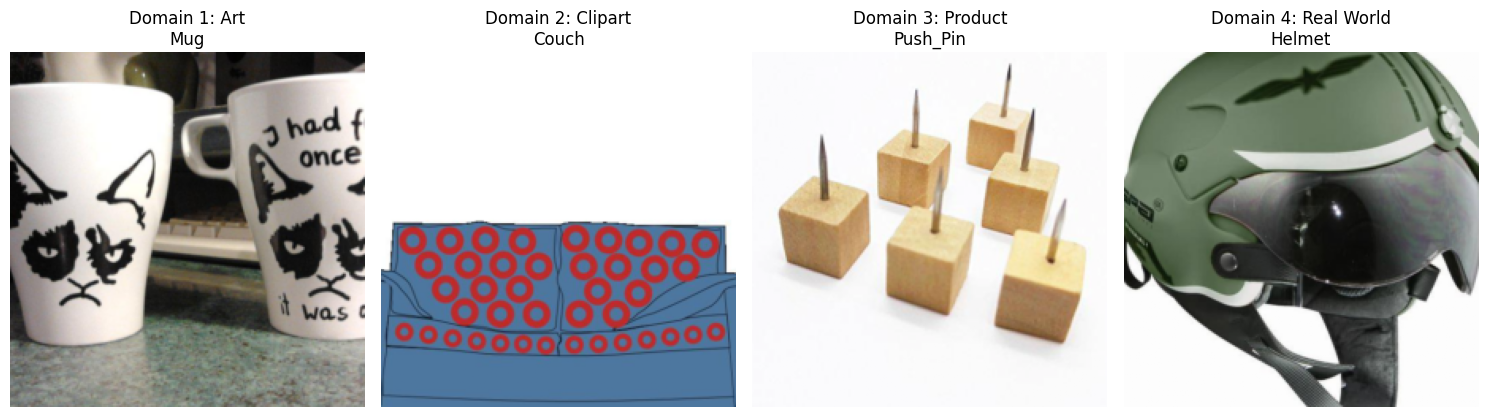

In [12]:
if not os.path.exists(DATA_DIR):
    dataset_root = extract_officehome()
else:
    dataset_root = [os.path.join(DATA_DIR, d) for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))][0]

officehome_classes = get_classes(dataset_root)
print(f"Classes: {officehome_classes}")

if not os.path.exists(PNG_DIR):
    save_pngs(dataset_root, officehome_classes)
else:
    print(f"PNGs already exist -> {PNG_DIR}")

all_loaders = build_all_domains(officehome_classes, num_workers=2)
print("All domain loaders ready.")

# Extract the 4 Domains Sequentially
sequential_train_loaders = [all_loaders[domain]["train"] for domain in range(1, 5)]
sequential_val_loaders = [all_loaders[domain]["val"] for domain in range(1, 5)]
sequential_test_loaders = [all_loaders[domain]["test"] for domain in range(1, 5)]

visualize_domain_samples(all_loaders, officehome_classes)

# OGD Execution Loop


Starting Sequential Training with OGD...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]



--- OGD Training on Domain 1: Art ---
   Epoch 1/10 - Loss: 4.3301
   Epoch 2/10 - Loss: 3.8324
   Epoch 3/10 - Loss: 3.0368
   Epoch 4/10 - Loss: 2.2007
   Epoch 5/10 - Loss: 1.6704
   Epoch 6/10 - Loss: 1.3489
   Epoch 7/10 - Loss: 1.1231
   Epoch 8/10 - Loss: 0.9813
   Epoch 9/10 - Loss: 0.9093
   Epoch 10/10 - Loss: 0.8793
   Validation Accuracy on Domain 1: 61.93%
   Test Accuracy on Domain 1: 59.02%

--- OGD Training on Domain 2: Clipart ---
   Epoch 1/10 - Loss: 2.9361
   Epoch 2/10 - Loss: 2.3168
   Epoch 3/10 - Loss: 1.5506
   Epoch 4/10 - Loss: 1.0579
   Epoch 5/10 - Loss: 0.7723
   Epoch 6/10 - Loss: 0.5820
   Epoch 7/10 - Loss: 0.4613
   Epoch 8/10 - Loss: 0.3874
   Epoch 9/10 - Loss: 0.3434
   Epoch 10/10 - Loss: 0.3292
   Validation Accuracy on Domain 2: 70.83%
   Test Accuracy on Domain 1: 51.13%
   Test Accuracy on Domain 2: 70.50%

--- OGD Training on Domain 3: Product ---
   Epoch 1/10 - Loss: 1.8030
   Epoch 2/10 - Loss: 1.2815
   Epoch 3/10 - Loss: 0.8045
   Epoch 

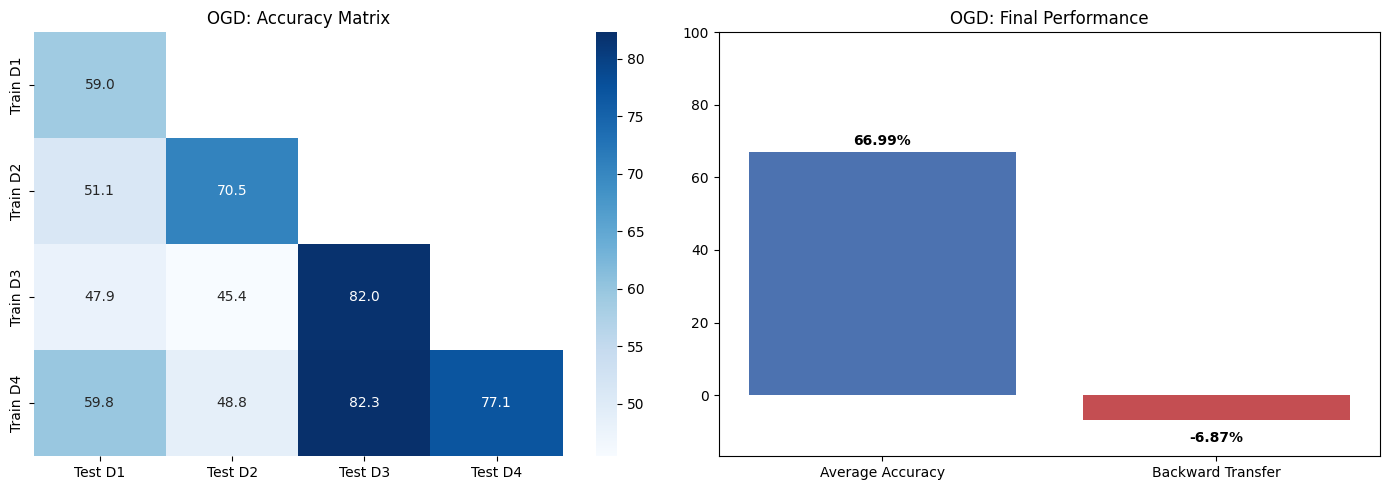

In [18]:
print(f"\n{'='*50}")
print("Starting Sequential Training with OGD...")
print(f"{'='*50}")

model = get_officehome_resnet18(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = OGD(model)
method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- OGD Training on Domain {task_id + 1}: {DOMAIN_FOLDERS[task_id + 1]} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=len(task_dataloader), epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    method.update_basis(task_dataloader)

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)
    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "OGD")

# GEM Execution Loop


Starting Sequential Training with GEM...

--- GEM Training on Domain 1: Art ---
   Epoch 1/10 - Loss: 4.3887
   Epoch 2/10 - Loss: 3.9062
   Epoch 3/10 - Loss: 3.0612
   Epoch 4/10 - Loss: 2.2382
   Epoch 5/10 - Loss: 1.6766
   Epoch 6/10 - Loss: 1.3281
   Epoch 7/10 - Loss: 1.1166
   Epoch 8/10 - Loss: 0.9844
   Epoch 9/10 - Loss: 0.9135
   Epoch 10/10 - Loss: 0.8831
   Validation Accuracy on Domain 1: 61.01%
   Test Accuracy on Domain 1: 57.71%

--- GEM Training on Domain 2: Clipart ---
   Epoch 1/10 - Loss: 2.9414
   Epoch 2/10 - Loss: 2.3013
   Epoch 3/10 - Loss: 1.5372
   Epoch 4/10 - Loss: 1.0641
   Epoch 5/10 - Loss: 0.7779
   Epoch 6/10 - Loss: 0.5874
   Epoch 7/10 - Loss: 0.4672
   Epoch 8/10 - Loss: 0.3906
   Epoch 9/10 - Loss: 0.3495
   Epoch 10/10 - Loss: 0.3333
   Validation Accuracy on Domain 2: 71.32%
   Test Accuracy on Domain 1: 55.83%
   Test Accuracy on Domain 2: 67.90%

--- GEM Training on Domain 3: Product ---
   Epoch 1/10 - Loss: 1.8124
   Epoch 2/10 - Loss: 1.2

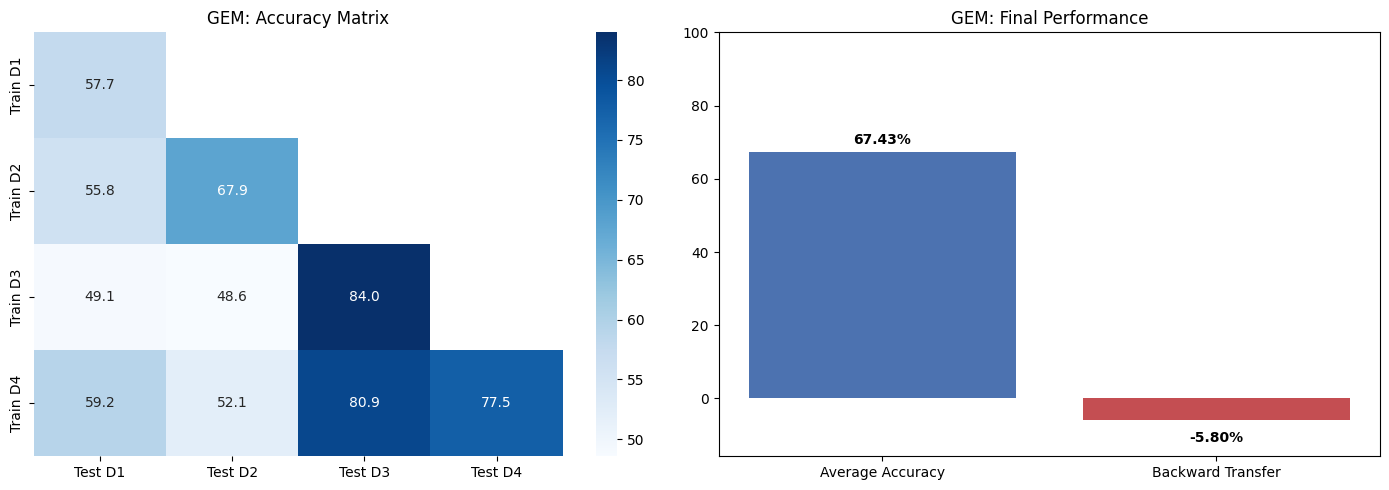

In [19]:
print(f"\n{'='*50}")
print("Starting Sequential Training with GEM...")
print(f"{'='*50}")

model = get_officehome_resnet18(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = GEM(model)
method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- GEM Training on Domain {task_id + 1}: {DOMAIN_FOLDERS[task_id + 1]} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=len(task_dataloader), epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients(task_id, loss_fn)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    mem_x, mem_y = next(iter(task_dataloader))
    method.update_memory(task_id, mem_x.to(device), mem_y.to(device))

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)
    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "GEM")

# PCGrad Execution Loop


Starting Sequential Training with PCGrad...

--- PCGrad Training on Domain 1: Art ---
   Epoch 1/10 - Loss: 4.3707
   Epoch 2/10 - Loss: 3.8977
   Epoch 3/10 - Loss: 3.0556
   Epoch 4/10 - Loss: 2.2133
   Epoch 5/10 - Loss: 1.6780
   Epoch 6/10 - Loss: 1.3594
   Epoch 7/10 - Loss: 1.1310
   Epoch 8/10 - Loss: 0.9905
   Epoch 9/10 - Loss: 0.9211
   Epoch 10/10 - Loss: 0.8974
   Validation Accuracy on Domain 1: 61.47%
   Test Accuracy on Domain 1: 56.58%

--- PCGrad Training on Domain 2: Clipart ---
   Epoch 1/10 - Loss: 2.9044
   Epoch 2/10 - Loss: 2.2569
   Epoch 3/10 - Loss: 1.4468
   Epoch 4/10 - Loss: 0.9622
   Epoch 5/10 - Loss: 0.6701
   Epoch 6/10 - Loss: 0.4912
   Epoch 7/10 - Loss: 0.3828
   Epoch 8/10 - Loss: 0.3146
   Epoch 9/10 - Loss: 0.2783
   Epoch 10/10 - Loss: 0.2616
   Validation Accuracy on Domain 2: 68.87%
   Test Accuracy on Domain 1: 57.14%
   Test Accuracy on Domain 2: 68.11%

--- PCGrad Training on Domain 3: Product ---
   Epoch 1/10 - Loss: 1.6750
   Epoch 2/10

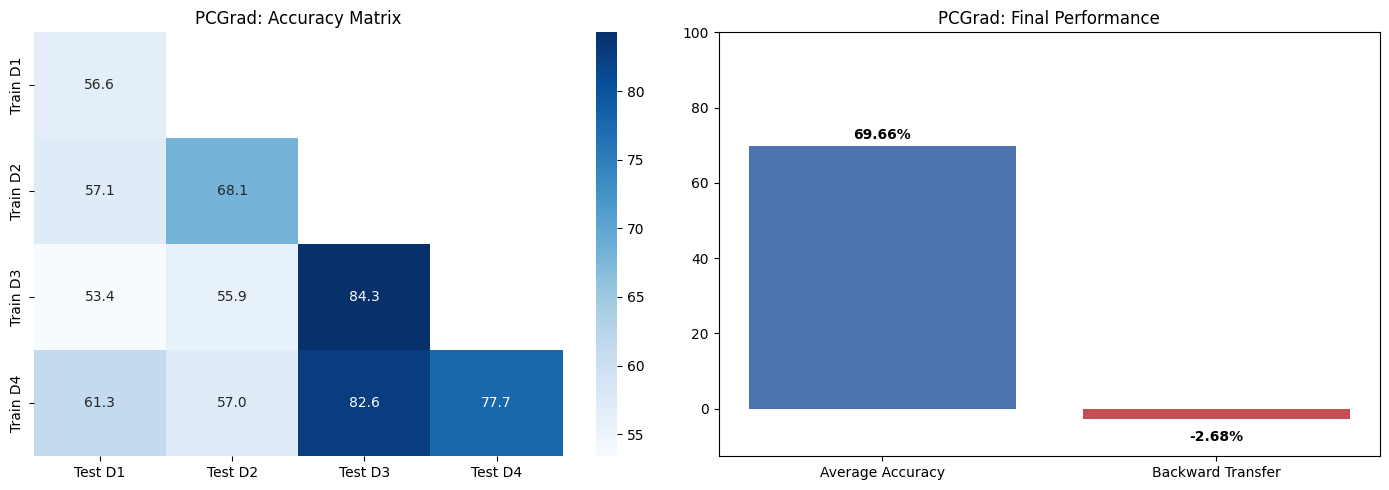

In [20]:
print(f"\n{'='*50}")
print("Starting Sequential Training with PCGrad...")
print(f"{'='*50}")

model = get_officehome_resnet18(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = PCGrad(model)
method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- PCGrad Training on Domain {task_id + 1}: {DOMAIN_FOLDERS[task_id + 1]} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=len(task_dataloader), epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients(loss_fn)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    mem_x, mem_y = next(iter(task_dataloader))
    method.update_memory(mem_x.to(device), mem_y.to(device))

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)
    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "PCGrad")